In [16]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats

import dask.dataframe as dd
from pathlib import Path
import re

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [17]:
import sys

sys.path.append("../src")
sys.path.append("../src/activity")

In [18]:
import subsampling as ss
import activity.activity_assembly as actvt
from core import SITE_NAMES, FREQ_GROUPS

from cli import get_file_paths
import plot
import pipeline

In [19]:
import suncalc

import activity.activity_assembly as actvt

from core import DC_COLOR_MAPPINGS, SEATTLE_LATITUDE, SEATTLE_LONGITUDE

In [20]:
avail = np.arange(0, 720, 6) + 6
reset_24 = avail[np.where((24*60 % avail) == 0)[0]]
reset_24

array([  6,  12,  18,  24,  30,  36,  48,  60,  72,  90,  96, 120, 144,
       180, 240, 288, 360, 480, 720])

In [21]:
cycle_lengths = [10]
percent_ons = [1/2]
specific_dc_tag = "30of30"

data_params = dict()
data_params["year"] = '2022'
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(data_params["cycle_lengths"], data_params["percent_ons"])
data_params["dc_tags"] = dc_tags
data_params["cur_dc_tag"] = specific_dc_tag
data_params['detector_tag'] = 'bd2'
data_params['bin_size'] = '30'
data_params['det_prob_threshold'] = 0.35
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'

pipeline_params = dict()
pipeline_params['assemble_location_summary'] = True
pipeline_params["read_csv"] = False
pipeline_params["save_activity_grid"] = False
pipeline_params["save_presence_grid"] = False
pipeline_params["save_dc_night_comparisons"] = False
pipeline_params["save_activity_dc_comparisons"] = True
pipeline_params["save_presence_dc_comparisons"] = True
pipeline_params["show_plots"] = True
pipeline_params["show_PST"] = True

In [22]:
site_key = 'Carp'
type_key = ''
data_params["site_name"] = SITE_NAMES[site_key]
data_params["site_tag"] = site_key
data_params["type_tag"] = type_key

file_paths = get_file_paths(data_params)

In [23]:
init_location_sum = actvt.assemble_initial_location_summary(file_paths) 
init_location_sum.reset_index(inplace=True)
init_location_sum.rename({'index':'index_in_file'}, axis='columns', inplace=True)
init_location_sum

,index_in_file,ref_time,call_start_time,call_end_time,start_time,end_time,low_freq,high_freq,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
0,0,2022-07-13 00:00:51.839500,2022-07-13 00:00:51.839500,2022-07-13 00:00:51.854300,51.8395,51.8543,22890.0,27138.0,Echolocation,Nyctalus leisleri,0.096,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
1,1,2022-07-13 00:01:17.840500,2022-07-13 00:01:17.840500,2022-07-13 00:01:17.855800,77.8405,77.8558,22890.0,26911.0,Echolocation,Nyctalus leisleri,0.095,0.204,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
2,2,2022-07-13 00:03:34.287500,2022-07-13 00:03:34.287500,2022-07-13 00:03:34.298800,214.2875,214.2988,32343.0,37435.0,Echolocation,Pipistrellus nathusii,0.162,0.355,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
3,3,2022-07-13 00:04:20.330500,2022-07-13 00:04:20.330500,2022-07-13 00:04:20.343800,260.3305,260.3438,24609.0,29278.0,Echolocation,Nyctalus leisleri,0.133,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
4,4,2022-07-13 00:04:45.531500,2022-07-13 00:04:45.531500,2022-07-13 00:04:45.539600,285.5315,285.5396,43515.0,47936.0,Echolocation,Pipistrellus pipistrellus,0.205,0.216,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430081,2,2022-10-17 15:37:12.995500,2022-10-17 15:37:12.995500,2022-10-17 15:37:13.011500,432.9955,433.0115,22031.0,27095.0,Echolocation,Nyctalus noctula,0.098,0.207,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2430082,3,2022-10-17 15:42:37.264500,2022-10-17 15:42:37.264500,2022-10-17 15:42:37.280400,757.2645,757.2804,11718.0,17316.0,Echolocation,Nyctalus leisleri,0.138,0.203,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2430083,4,2022-10-17 15:45:42.987500,2022-10-17 15:45:42.987500,2022-10-17 15:45:42.993700,942.9875,942.9937,22890.0,34055.0,Echolocation,Plecotus austriacus,0.106,0.201,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2430084,5,2022-10-17 15:49:20.239500,2022-10-17 15:49:20.239500,2022-10-17 15:49:20.257500,1160.2395,1160.2575,21171.0,24995.0,Echolocation,Nyctalus noctula,0.099,0.204,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795


In [24]:
def add_frequency_group_to_file_dets(file_dets, location_classes):
    file_classes = location_classes[pd.to_datetime(location_classes['file_name'], 
                                                   format='%Y%m%d_%H%M%S.WAV', exact=False)==file_dets.name].copy()

    file_dets.insert(0, 'index_in_summary', file_dets.index)
    file_dets.set_index('index_in_file', inplace=True)

    classified = file_classes['KMEANS_CLASSES']!=''
    file_classes.loc[classified, 'peak_frequency'] = file_classes.loc[classified, 'peak_frequency'].astype('float64')
    file_classes.loc[classified, 'SNR'] = file_classes.loc[classified, 'SNR'].astype('float64')

    file_dets.insert(0, 'peak_frequency', [np.NaN]*len(file_dets))
    file_dets.insert(0, 'SNR', [np.NaN]*len(file_dets))
    file_dets.loc[file_classes['index_in_file'], 'freq_group'] = file_classes['KMEANS_CLASSES'].values
    file_dets.loc[file_classes['index_in_file'], 'peak_frequency'] = file_classes['peak_frequency'].values
    file_dets.loc[file_classes['index_in_file'], 'SNR'] = file_classes['SNR'].values

    for group in ['LF', 'HF']:
        group_classified_dets = (file_dets['freq_group']==group)

        low_assert1 = (file_dets.loc[group_classified_dets, 'peak_frequency'] > (file_dets.loc[group_classified_dets, 'low_freq']).median()-4000)
        low_assert2 = (file_dets.loc[group_classified_dets, 'peak_frequency'] > (file_dets.loc[group_classified_dets, 'low_freq'])-4000)
        assert(low_assert1|low_assert2).all()
        high_assert1 = (file_dets.loc[group_classified_dets, 'peak_frequency'] < (file_dets.loc[group_classified_dets, 'high_freq']).median()+4000)
        high_assert2 = (file_dets.loc[group_classified_dets, 'peak_frequency'] < (file_dets.loc[group_classified_dets, 'high_freq'])+4000)
        assert(high_assert1|high_assert2).all()

    return file_dets

def add_frequency_groups_to_summary_using_kmeans(location_df, file_paths, data_params, save=True):
    location_df.insert(0, 'freq_group', '')
    location_classes = pd.read_csv(Path(file_paths['SITE_classes_file']), index_col=0)
    location_df.insert(0, 'input_file_dt', pd.to_datetime(location_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))
    location_df_grouped = location_df.groupby('input_file_dt', group_keys=True)

    location_df_classified = location_df_grouped.apply(lambda x: add_frequency_group_to_file_dets(x, location_classes))

    location_df_only_classified = location_df_classified.loc[location_df_classified['freq_group']!='']
    location_df_only_classified = location_df_only_classified.droplevel(level=0)
    location_df_only_classified = location_df_only_classified.reset_index()

    if data_params['type_tag'] != '':
        location_df_only_classified = location_df_only_classified.loc[location_df_only_classified['freq_group']==data_params['type_tag']]

    if save:
        location_df_only_classified.to_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv')

    return location_df_only_classified

In [25]:
# location_sum = add_frequency_groups_to_summary_using_kmeans(init_location_sum.copy(), file_paths, data_params)
location_df = init_location_sum.copy()
location_df.insert(0, 'freq_group', '')
location_classes = pd.read_csv(Path(file_paths['SITE_classes_file']), index_col=0)
location_df.insert(0, 'input_file_dt', pd.to_datetime(location_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False))
location_df_grouped = location_df.groupby('input_file_dt', group_keys=True)
location_classes

,index,KMEANS_CLASSES,peak_frequency,SNR,index_in_file,index_in_summary,file_name,sampling_rate
0,0,LF,25920.0,0.521283,0,0,20220713_000000.WAV,250000
1,1,LF,24000.0,0.337537,1,1,20220713_000000.WAV,250000
2,2,LF,32640.0,2.176484,2,2,20220713_000000.WAV,250000
3,3,LF,24960.0,0.537953,3,3,20220713_000000.WAV,250000
4,4,HF,44160.0,0.895821,4,4,20220713_000000.WAV,250000
...,...,...,...,...,...,...,...,...
2393577,0,LF,23040.0,0.707480,1,2430080,20221017_153000.WAV,192000
2393578,1,LF,23040.0,0.373847,2,2430081,20221017_153000.WAV,192000
2393579,2,LF,25920.0,1.369189,4,2430083,20221017_153000.WAV,192000
2393580,3,LF,22080.0,0.349448,5,2430084,20221017_153000.WAV,192000


In [41]:
location_df_classified = location_df_grouped.apply(lambda x: add_frequency_group_to_file_dets(x, location_classes))

In [53]:
location_df_only_classified = location_df_classified.loc[location_df_classified['freq_group']!='']
location_df_only_classified = location_df_only_classified.droplevel(level=0)
location_df_only_classified = location_df_only_classified.reset_index()

In [54]:
location_df_only_classified

,index_in_file,SNR,peak_frequency,index_in_summary,input_file_dt,freq_group,ref_time,call_start_time,call_end_time,start_time,...,event,class,class_prob,det_prob,individual,input_file,Site name,Recover Folder,SD Card,File Duration
0,0,0.521283,25920.0,0,2022-07-13 00:00:00,LF,2022-07-13 00:00:51.839500,2022-07-13 00:00:51.839500,2022-07-13 00:00:51.854300,51.8395,...,Echolocation,Nyctalus leisleri,0.096,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
1,1,0.337537,24000.0,1,2022-07-13 00:00:00,LF,2022-07-13 00:01:17.840500,2022-07-13 00:01:17.840500,2022-07-13 00:01:17.855800,77.8405,...,Echolocation,Nyctalus leisleri,0.095,0.204,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
2,2,2.176484,32640.0,2,2022-07-13 00:00:00,LF,2022-07-13 00:03:34.287500,2022-07-13 00:03:34.287500,2022-07-13 00:03:34.298800,214.2875,...,Echolocation,Pipistrellus nathusii,0.162,0.355,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
3,3,0.537953,24960.0,3,2022-07-13 00:00:00,LF,2022-07-13 00:04:20.330500,2022-07-13 00:04:20.330500,2022-07-13 00:04:20.343800,260.3305,...,Echolocation,Nyctalus leisleri,0.133,0.227,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
4,4,0.895821,44160.0,4,2022-07-13 00:00:00,HF,2022-07-13 00:04:45.531500,2022-07-13 00:04:45.531500,2022-07-13 00:04:45.539600,285.5315,...,Echolocation,Pipistrellus pipistrellus,0.205,0.216,-1,/mnt/ubna_data_01_mir/recover-20220715/UBNA_00...,Carp Pond,recover-20220715,8,1795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2393577,1,0.707480,23040.0,2430080,2022-10-17 15:30:00,LF,2022-10-17 15:35:21.171500,2022-10-17 15:35:21.171500,2022-10-17 15:35:21.191100,321.1715,...,Echolocation,Nyctalus leisleri,0.114,0.226,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2393578,2,0.373847,23040.0,2430081,2022-10-17 15:30:00,LF,2022-10-17 15:37:12.995500,2022-10-17 15:37:12.995500,2022-10-17 15:37:13.011500,432.9955,...,Echolocation,Nyctalus noctula,0.098,0.207,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2393579,4,1.369189,25920.0,2430083,2022-10-17 15:30:00,LF,2022-10-17 15:45:42.987500,2022-10-17 15:45:42.987500,2022-10-17 15:45:42.993700,942.9875,...,Echolocation,Plecotus austriacus,0.106,0.201,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795
2393580,5,0.349448,22080.0,2430084,2022-10-17 15:30:00,LF,2022-10-17 15:49:20.239500,2022-10-17 15:49:20.239500,2022-10-17 15:49:20.257500,1160.2395,...,Echolocation,Nyctalus noctula,0.099,0.204,-1,/mnt/ubna_data_02_mir/recover-20221017/UBNA_01...,Carp Pond,recover-20221017,10,1795


In [67]:
location_kmeans_df = pipeline.prepare_location_sumary(data_params, pipeline_params, file_paths)

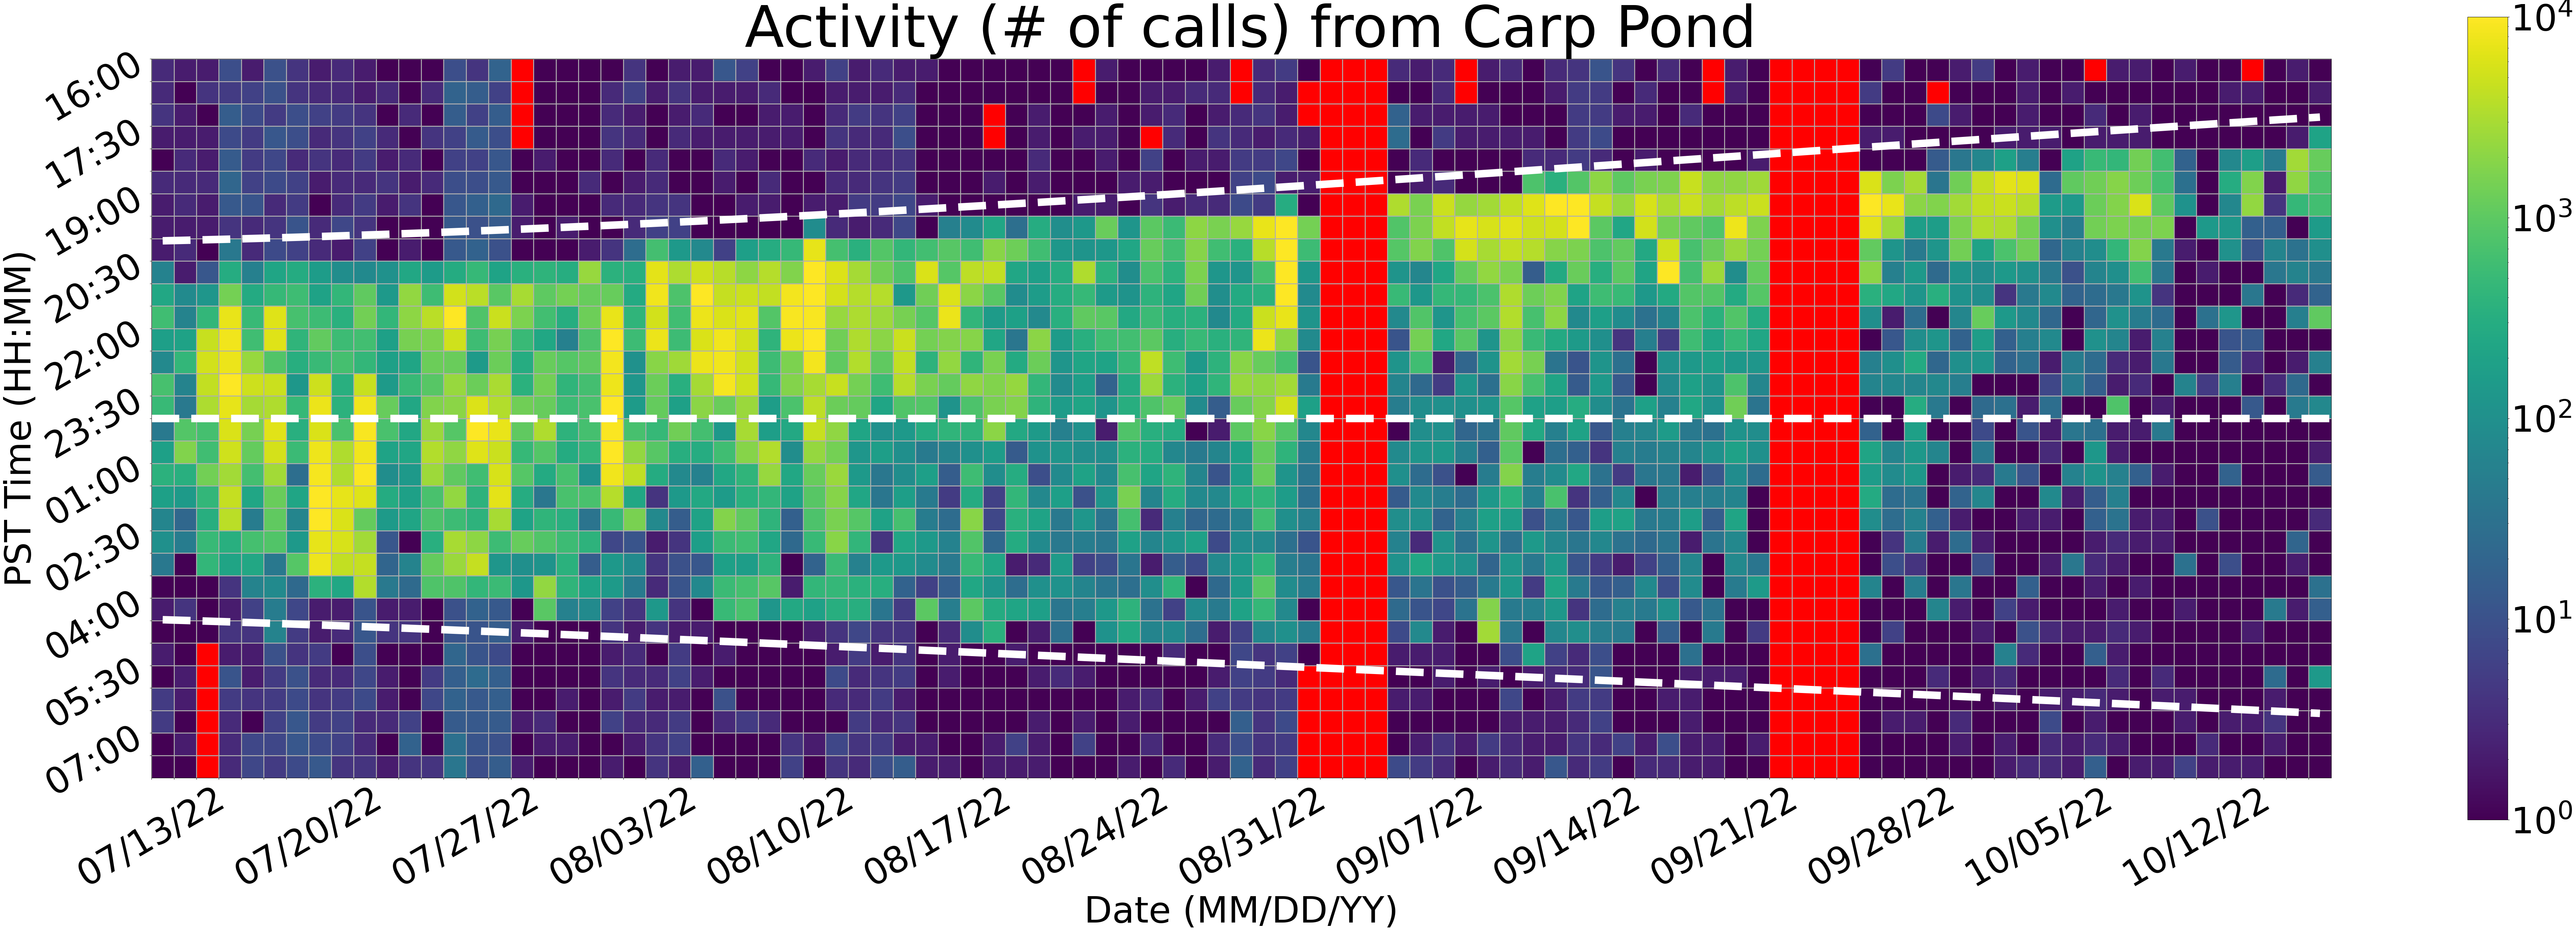

In [70]:
activity_dets_arr = actvt.generate_activity_dets_results(data_params, file_paths)
plot.plot_activity_grid_for_dets(activity_dets_arr, data_params, pipeline_params, file_paths)